<div style="text-align: center">
    <h2>SOCIAL MEDIA TREND ANALYSIS</h2>
</div>

***IMPORT THE IMPORTANT LIBRARIES FOR ALL TASKS HELPING IN WEB SCRAPING, DATA MANIPULATION AND SAVING DATA IN CSV FILES***

In [1]:
import time
import re
import csv
import pandas as pd
from bs4 import BeautifulSoup
from selenium import webdriver
import matplotlib.pyplot as plt
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support import expected_conditions as EC
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

***CREATE VARIABLES FOR THE TWITTER ADVANCED FILTERED SEARCH URLS FOR FOUR AREAS: POLITICS, ENTERTAINMENT, TECHNOLOGY AND SPORTS***

In [2]:
TWITTER_URL_POLITICS = 'https://x.com/search?q=(%23Politics%20OR%20%23OR%20OR%20%23PoliticalNews%20OR%20%23OR%20OR%20%23Election%20OR%20%23OR%20OR%20%23Government%20OR%20%23OR%20OR%20%23Democracy%20OR%20%23OR%20OR%20%23Policy%20OR%20%23OR%20OR%20%23Vote%20OR%20%23OR%20OR%20%23Campaign%20OR%20%23OR%20OR%20%23PoliticalDebate%20OR%20%23OR%20OR%20%23BreakingPolitics)%20min_faves%3A50%20lang%3Aen%20until%3A2025-03-16%20since%3A2025-03-15&src=typed_query'
TWITTER_URL_ENTERTAINMENT = 'https://x.com/search?q=(%23Entertainment%20OR%20%23OR%20OR%20%23Movies%20OR%20%23OR%20OR%20%23Music%20OR%20%23OR%20OR%20%23TVShows%20OR%20%23OR%20OR%20%23CelebrityNews%20OR%20%23OR%20OR%20%23Hollywood%20OR%20%23OR%20OR%20%23Bollywood%20OR%20%23OR%20OR%20%23FilmIndustry%20OR%20%23OR%20OR%20%23PopCulture%20OR%20%23OR%20OR%20%23RedCarpet)%20min_faves%3A50%20lang%3Aen%20until%3A2025-03-16%20since%3A2025-03-15&src=typed_query'
TWITTER_URL_TECHNOLOGY = 'https://x.com/search?q=(%23Technology%20OR%20%23OR%20OR%20%23TechNews%20OR%20%23OR%20OR%20%23Innovation%20OR%20%23OR%20OR%20%23ArtificialIntelligence%20OR%20%23OR%20OR%20%23MachineLearning%20OR%20%23OR%20OR%20%23CyberSecurity%20OR%20%23OR%20OR%20%23Gadgets%20OR%20%23OR%20OR%20%23TechTrends%20OR%20%23OR%20OR%20%23Programming%20OR%20%23OR%20OR%20%23Coding)%20min_faves%3A49%20lang%3Aen%20until%3A2025-03-16%20since%3A2025-03-15&src=typed_query'
TWITTER_URL_SPORTS = 'https://x.com/search?q=(%23Sports%20OR%20%23OR%20OR%20%23Football%20OR%20%23OR%20OR%20%23Cricket%20OR%20%23OR%20OR%20%23Basketball%20OR%20%23OR%20OR%20%23Tennis%20OR%20%23OR%20OR%20%23Olympics%20OR%20%23OR%20OR%20%23WorldCup%20OR%20%23OR%20OR%20%23Athlete%20OR%20%23OR%20OR%20%23SportsNews%20OR%20%23OR%20OR%20%23LiveSports)%20min_faves%3A50%20lang%3Aen%20until%3A2025-03-16%20since%3A2025-03-15&src=typed_query'

***ENTER YOUR TWITTER USERNAME AND PASSWORD***

In [167]:
twitter_username = <your username>
twitter_password = <your password>

***SCRAPE THE TWITTER TWEETS WITH THE HELP OF ADVANCED URLS***

In [168]:
# Set up Chrome options
options = Options()
options.add_argument("--start-maximized")  # Open in full screen

# Start Chrome driver
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

# Twitter login URL
twitter_login_url = "https://twitter.com/login"

# Twitter credentials
TWITTER_USERNAME = twitter_username
TWITTER_PASSWORD = twitter_password

# Function to log in
def login_to_twitter():
    driver.get(twitter_login_url)
    
    wait = WebDriverWait(driver, 15)
    
    # Enter username
    username_field = wait.until(EC.presence_of_element_located((By.NAME, "text")))
    username_field.send_keys(TWITTER_USERNAME)
    username_field.send_keys(Keys.ENTER)
    time.sleep(2)  # Wait for password field
    
    # Enter password
    password_field = wait.until(EC.presence_of_element_located((By.NAME, "password")))
    password_field.send_keys(TWITTER_PASSWORD)
    password_field.send_keys(Keys.ENTER)
    
    time.sleep(5)  # Wait for login to complete

# Log in to Twitter
login_to_twitter()

# Twitter Advanced Search URL
twitter_url_politics = TWITTER_URL_POLITICS
twitter_url_entertainment = TWITTER_URL_ENTERTAINMENT
twitter_url_technology = TWITTER_URL_TECHNOLOGY
twitter_url_sports = TWITTER_URL_SPORTS

areas = ['politics', 'entertainment', 'technology', 'sports']

for i,j in enumerate([twitter_url_politics, twitter_url_entertainment, twitter_url_technology, twitter_url_sports]):

    driver.get(j)
    
    # Wait for tweets to load
    wait = WebDriverWait(driver, 15)
    wait.until(EC.presence_of_element_located((By.TAG_NAME, "article")))
    
    # Scroll down to load more tweets
    tweet_count = 0
    max_tweets = 100
    all_tweets = []
    
    while tweet_count < max_tweets:
        driver.find_element(By.TAG_NAME, "body").send_keys(Keys.END)
        time.sleep(10)  # Allow time for new tweets to load
        tweet_count += 10  # Approximate count per scroll
        
        # Get page source and parse with BeautifulSoup
        soup = BeautifulSoup(driver.page_source, "html.parser")
        
        # Find all tweet elements
        tweets = soup.find_all("article", {"data-testid": "tweet"})
    
        for tweet in tweets[:max_tweets]:  # Get top 100 tweets
            if re.search(r'lang="(.*?)"', tweet.prettify()).group(1) == 'en':
                tweet_string = tweet.prettify()
                
                date = re.search(r'datetime="(.*?)T', tweet_string)
                date = date.group(1)
                
                likes = re.search(r'(\d+) likes', tweet_string)
                likes = likes.group(1)
                
                final_tweet = ''
                text = re.search(r'tweetText(.*?)</div>', tweet_string, re.DOTALL)
                matches = re.findall(r'<span.*>(.*?)</span>', text.group(1), re.DOTALL)
                for k in matches:
                    final_tweet += k.strip()

                all_tweets.append([date, final_tweet, likes])

    # Save all tweets to CSV at once
    with open(f'tweet_{areas[i]}.csv', "w", encoding="utf-8", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["Date", "Tweet", "Likes"])
        writer.writerows(all_tweets)
     
    print(f"Tweets saved to tweet_{areas[i]}.csv")
    
# Close the browser
driver.quit()

Tweets saved to tweet_politics.csv
Tweets saved to tweet_entertainment.csv
Tweets saved to tweet_technology.csv
Tweets saved to tweet_sports.csv


***CREATE DEDICATED DATAFRAMES FOR EACH TYPE OF CSV FILE CREATED***

In [2]:
df_pol = pd.read_csv('tweet_politics.csv')
df_en = pd.read_csv('tweet_entertainment.csv')
df_tech = pd.read_csv('tweet_technology.csv')
df_sp = pd.read_csv('tweet_sports.csv')

***PRINT THE TOP 5 ROWS OF EACH DATAFRAME***

In [3]:
df_pol.head()

,Date,Tweet,Likes
0,2025-03-15,NaN,330
1,2025-03-15,!,3608
2,2025-03-15,"I’m going to leave this here, just as an illus...",711
3,2025-03-15,"I’m going to leave this here, just as an illus...",711
4,2025-03-15,Minorities can't walk the streets without fear...,827


In [4]:
df_en.head()

,Date,Tweet,Likes
0,2025-03-15,The best beginning and ending of one of the mo...,2885
1,2025-03-15,Wow. You could watch “A Star is Born” and then...,6406
2,2025-03-15,NaN,570
3,2025-03-15,NaN,570
4,2025-03-15,NaN,351


In [5]:
df_tech.head()

,Date,Tweet,Likes
0,2025-03-15,Reactive Agents –Act,1265
1,2025-03-15,Event-driven architecture is a design pattern ...,528
2,2025-03-15,AI is going to be extremely useful in counteri...,2542
3,2025-03-15,"If you're not using AI, you're falling behind....",292
4,2025-03-15,…,637


In [6]:
df_sp.head()

,Date,Tweet,Likes
0,2025-03-15,"through sports,",759
1,2025-03-15,NaN,367
2,2025-03-15,Head to Matchday Live for live coverage from a...,695
3,2025-03-15,NaN,160
4,2025-03-15,NaN,342


***ANALYSIS PERIOD -> 15TH MARCH 2025 (1 DAY)***

In [10]:
df_pol.Date.value_counts(),df_en.Date.value_counts(),df_tech.Date.value_counts(),df_sp.Date.value_counts()

(Date
 2025-03-15    25
 Name: count, dtype: int64,
 Date
 2025-03-15    44
 Name: count, dtype: int64,
 Date
 2025-03-15    41
 Name: count, dtype: int64,
 Date
 2025-03-15    43
 Name: count, dtype: int64)

***CREATE A COLUMN IN EACH DATAFRAME MENTIONING THE TYPE OF TWEET***

In [47]:
df_pol['hashtag'] = 'politics'
df_en['hashtag'] = 'entertainment'
df_tech['hashtag'] = 'technology'
df_sp['hashtag'] = 'sports'

In [48]:
df_pol.head()

,Date,Tweet,Likes,hashtag
0,2025-03-15,NaN,330,politics
1,2025-03-15,!,3608,politics
2,2025-03-15,"I’m going to leave this here, just as an illus...",711,politics
3,2025-03-15,"I’m going to leave this here, just as an illus...",711,politics
4,2025-03-15,Minorities can't walk the streets without fear...,827,politics


In [49]:
df_en.head()

,Date,Tweet,Likes,hashtag
0,2025-03-15,The best beginning and ending of one of the mo...,2885,entertainment
1,2025-03-15,Wow. You could watch “A Star is Born” and then...,6406,entertainment
2,2025-03-15,NaN,570,entertainment
3,2025-03-15,NaN,570,entertainment
4,2025-03-15,NaN,351,entertainment


In [50]:
df_tech.head()

,Date,Tweet,Likes,hashtag
0,2025-03-15,Reactive Agents –Act,1265,technology
1,2025-03-15,Event-driven architecture is a design pattern ...,528,technology
2,2025-03-15,AI is going to be extremely useful in counteri...,2542,technology
3,2025-03-15,"If you're not using AI, you're falling behind....",292,technology
4,2025-03-15,…,637,technology


In [51]:
df_sp.head()

,Date,Tweet,Likes,hashtag
0,2025-03-15,"through sports,",759,sports
1,2025-03-15,NaN,367,sports
2,2025-03-15,Head to Matchday Live for live coverage from a...,695,sports
3,2025-03-15,NaN,160,sports
4,2025-03-15,NaN,342,sports


***CONCATENATING ALL THE DATAFRAMES INTO A SINGLE DATAFRAME***

In [52]:
df_final_tweets = pd.concat([df_pol,df_en,df_tech,df_sp])

In [53]:
df_final_tweets.sample(10)

,Date,Tweet,Likes,hashtag
34,2025-03-15,Would you rather your club win the Champions L...,643,sports
27,2025-03-15,It’s a bit of both but Europeans are loud all ...,516,sports
25,2025-03-15,Follow us for more updates about your favorite...,519,entertainment
29,2025-03-15,It’s a bit of both but Europeans are loud all ...,516,sports
30,2025-03-15,I genuinely hate that kids now don’t have chea...,3329,entertainment
21,2025-03-15,NaN,171,sports
7,2025-03-15,Hollywood doesn’t know how to market them. \n\...,229,entertainment
36,2025-03-15,NaN,586,technology
20,2025-03-15,The 2027 election will be centered around trus...,443,politics
30,2025-03-15,This man predicts the future:\n\nMasayoshi Son...,1417,technology


In [54]:
df_final_tweets.shape

(153, 4)

***HANDLING NULL VALUES***

In [55]:
df_final_tweets.isna().sum()

Date        0
Tweet      40
Likes       0
hashtag     0
dtype: int64

In [56]:
df_final_tweets.dropna(inplace=True)

In [57]:
df_final_tweets.shape

(113, 4)

In [58]:
df_final_tweets = df_final_tweets.drop_duplicates()

In [59]:
df_final_tweets.head()

,Date,Tweet,Likes,hashtag
1,2025-03-15,!,3608,politics
2,2025-03-15,"I’m going to leave this here, just as an illus...",711,politics
4,2025-03-15,Minorities can't walk the streets without fear...,827,politics
5,2025-03-15,Multiple generations fought to protect nationa...,629,politics
6,2025-03-15,I don't think some people understand the dang...,581,politics


In [60]:
df_final_tweets.shape

(96, 4)

***PERFORMING BASIC NLP - PREPROCESSING ON THE TWEETS***

In [61]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove punctuation/emojis
    return text.strip()

df_final_tweets['cleaned_tweet'] = df_final_tweets['Tweet'].apply(preprocess)
print(df_final_tweets[['Tweet', 'cleaned_tweet']])

                                                Tweet  \
1                                                   !   
2   I’m going to leave this here, just as an illus...   
4   Minorities can't walk the streets without fear...   
5   Multiple generations fought to protect nationa...   
6   I don't think some  people understand the dang...   
..                                                ...   
33  Chak De! India (2007) is a sports drama about ...   
34  Would you rather your club win the Champions L...   
35  is there a safe sport to root for? like low ri...   
40  After watching Cricket for nearly 30 years, I ...   
41  We can’t enjoy anything \n\nScore a goal? Can’...   

                                        cleaned_tweet  
1                                                      
2   im going to leave this here just as an illustr...  
4   minorities cant walk the streets without fear ...  
5   multiple generations fought to protect nationa...  
6   i dont think some  people under

***CALCULATING SENTIMENT SCORE WITH THE HELP OF A CLASS - SentimentIntensityAnalyzer() INSIDE VaderSentiment***

In [62]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score['compound']
    sentiment = 'Positive' if compound >= 0.05 else 'Negative' if compound <= -0.05 else 'Neutral'
    return sentiment, score['compound']

# Apply sentiment analysis
df_final_tweets[['Sentiment', 'Compound_Score']] = df_final_tweets['cleaned_tweet'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(df_final_tweets[['Tweet', 'Sentiment', 'Compound_Score']])

                                                Tweet Sentiment  \
1                                                   !   Neutral   
2   I’m going to leave this here, just as an illus...  Negative   
4   Minorities can't walk the streets without fear...  Negative   
5   Multiple generations fought to protect nationa...  Negative   
6   I don't think some  people understand the dang...  Negative   
..                                                ...       ...   
33  Chak De! India (2007) is a sports drama about ...   Neutral   
34  Would you rather your club win the Champions L...  Positive   
35  is there a safe sport to root for? like low ri...  Negative   
40  After watching Cricket for nearly 30 years, I ...   Neutral   
41  We can’t enjoy anything \n\nScore a goal? Can’...  Negative   

    Compound_Score  
1           0.0000  
2          -0.3678  
4          -0.5679  
5          -0.7003  
6          -0.8860  
..             ...  
33          0.0000  
34          0.9001  
35    

***PLOTTING THE PERCENTAGES OF ALL SENTIMENTS***

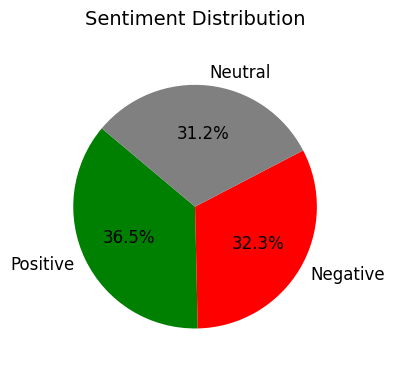

In [66]:
sentiment_counts = df_final_tweets['Sentiment'].value_counts()

plt.figure(figsize=(4,4))
sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',        # Show percentage with 1 decimal
    colors=['green', 'red', 'grey'],
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('Sentiment Distribution', fontsize=14)
plt.ylabel('')  # This removes the Y-axis label
plt.axis('equal')  # Makes it a perfect circle
plt.tight_layout()
plt.show()

In [64]:
df_final_tweets.head()

,Date,Tweet,Likes,hashtag,cleaned_tweet,Sentiment,Compound_Score
1,2025-03-15,!,3608,politics,,Neutral,0.0000
2,2025-03-15,"I’m going to leave this here, just as an illus...",711,politics,im going to leave this here just as an illustr...,Negative,-0.3678
4,2025-03-15,Minorities can't walk the streets without fear...,827,politics,minorities cant walk the streets without fear ...,Negative,-0.5679
5,2025-03-15,Multiple generations fought to protect nationa...,629,politics,multiple generations fought to protect nationa...,Negative,-0.7003
6,2025-03-15,I don't think some people understand the dang...,581,politics,i dont think some people understand the dange...,Negative,-0.8860


***SAVING THE FINAL DATAFRAME TO A CSV FILE***

In [65]:
df_final_tweets.to_csv("final_tweets.csv", index=False)

***CREATING POWER BI SPECIFIC CSV FILE USEFUL IN CREATING DASHBOARD***

In [68]:
df_power_bi = df_final_tweets.drop(['Date','Tweet','cleaned_tweet','Compound_Score'], axis = 1)

In [69]:
df_power_bi.head()

,Likes,hashtag,Sentiment
1,3608,politics,Neutral
2,711,politics,Negative
4,827,politics,Negative
5,629,politics,Negative
6,581,politics,Negative


In [70]:
df_power_bi.to_csv("final_tweets_bi.csv", index=False)